# Linear Regression - Practice

We will apply what you learned about linear regression for a new data set. 

The `Data` folder contains a `csv`-file containing information about CO$_2$ vehicle emissions for vehicles in Canada. 

You can now practice what you learned by 

1. loading the dataset into pandas
2. performing exploratory data analysis to understand
    - what the columns are?
    - descriptive statistics of numeric and text columns (e.g. value counts, mean, std)
3. make plots and calculate correlation coefficients to find linear correlations in the data
4. apply simple linear regression 
5. apply multiple linear regression 
6. explore the impact of the car type (a discrete variable) on CO$_2$ emissions

**Happy working!**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats
import statsmodels.formula.api as smf 
import statsmodels.api as sm 

In [15]:
co2_df = pd.read_csv('../data/CO2 Emissions_Canada.csv',
                          sep = ',',
                          na_values='NA',
                    )
co2_df.head()

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
0,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


In [16]:
co2_df.describe()

,Engine Size(L),Cylinders,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
count,7385.000000,7385.000000,7385.000000,7385.000000,7385.000000,7385.000000,7385.000000
mean,3.160068,5.615030,12.556534,9.041706,10.975071,27.481652,250.584699
std,1.354170,1.828307,3.500274,2.224456,2.892506,7.231879,58.512679
min,0.900000,3.000000,4.200000,4.000000,4.100000,11.000000,96.000000
25%,2.000000,4.000000,10.100000,7.500000,8.900000,22.000000,208.000000
50%,3.000000,6.000000,12.100000,8.700000,10.600000,27.000000,246.000000
75%,3.700000,6.000000,14.600000,10.200000,12.600000,32.000000,288.000000
max,8.400000,16.000000,30.600000,20.600000,26.100000,69.000000,522.000000


In [17]:
co2_df.groupby('Make')[['Model']].count()

,Model
Make,
ACURA,72
ALFA ROMEO,30
ASTON MARTIN,47
AUDI,286
BENTLEY,46
BMW,527
BUGATTI,3
BUICK,103
CADILLAC,158


In [18]:
co2_df.groupby('Model')[['Cylinders']].count()

,Cylinders
Model,
124 SPIDER,4
124 Spider,4
1500,7
1500 (MDS),6
1500 4X4,7
...,...
iM,2
iQ,2
tC,6


In [25]:
co2_ford_df = co2_df.loc[co2_df.Make == 'FORD']
co2_ford_df.head()

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
342,FORD,C-MAX HYBRID,FULL-SIZE,2.0,4,AV,X,5.6,6.4,6.0,47,138
343,FORD,E150 VAN FFV,VAN - CARGO,4.6,8,A4,X,17.7,14.4,16.2,17,373
344,FORD,E150 VAN FFV,VAN - CARGO,4.6,8,A4,E,24.1,19.2,21.9,13,350
345,FORD,E150 VAN FFV,VAN - CARGO,5.4,8,A4,X,19.3,14.7,17.2,16,396
346,FORD,E150 VAN FFV,VAN - CARGO,5.4,8,A4,E,24.9,19.6,22.5,13,360


<Axes: xlabel='Fuel Consumption Comb (mpg)', ylabel='CO2 Emissions(g/km)'>

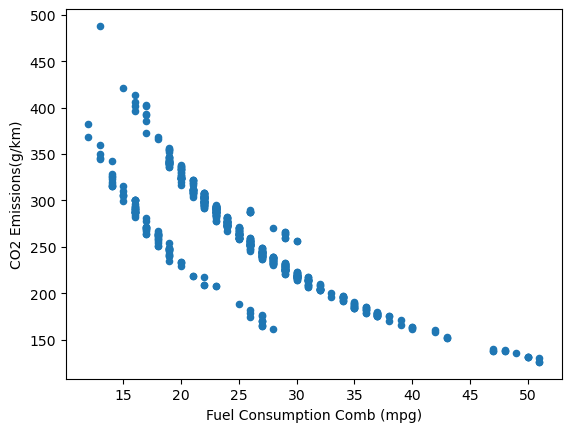

In [26]:
co2_ford_df.plot(kind = 'scatter', x='Fuel Consumption Comb (mpg)',y='CO2 Emissions(g/km)')

<Axes: xlabel='Engine Size(L)', ylabel='CO2 Emissions(g/km)'>

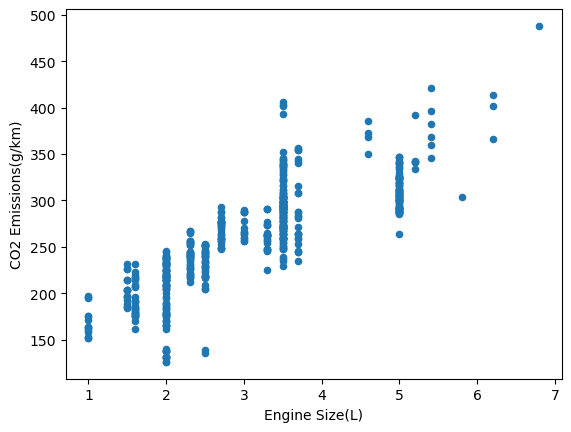

In [27]:
co2_ford_df.plot(kind = 'scatter', x='Engine Size(L)',y='CO2 Emissions(g/km)')